# Carbon Intensity — Calculation & Validation
**Carbon-Aware Compute Framework**

Covers Phase 2 of the framework:
- **Step 7** — Derive carbon intensity from ENTSO-E generation mix (method = `'derived'`)
- **Step 8** — Validate derived values against Electricity Maps (method = `'electricitymaps'`)

## Sections
- **A. Pre-flight checks** — confirm generation and emission_factors inputs are ready
- **B. Step 7: Calculation** — weighted average carbon intensity, write to `carbon_intensity`
- **C. Step 7: Sanity checks** — range validation against known expected values
- **D. Step 8: Validation** — MAE and correlation vs Electricity Maps over the overlap window
- **E. Findings summary** — per-country result table and methodology notes

In [17]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)
conn = psycopg2.connect(os.environ["DATABASE_URL"])

def query(sql, params=None):
    return pd.read_sql(sql, conn, params=params)

print("DB connected ✓")

DB connected ✓


---
## Section A — Pre-flight Checks
Confirm that all inputs required for Step 7 are present before running the calculation.

### A1. Generation table — country coverage and date range

In [2]:
gen_coverage = query("""
    SELECT
        country,
        COUNT(DISTINCT timestamp_utc)               AS distinct_hours,
        MIN(timestamp_utc)::date                    AS first_date,
        MAX(timestamp_utc)::date                    AS last_date,
        COUNT(DISTINCT source_type)                 AS source_types
    FROM generation
    GROUP BY country
    ORDER BY country
""")

if len(gen_coverage) == 0:
    print("⚠️  generation table is empty — run entsoe_ingest.ipynb first.")
else:
    print(gen_coverage.to_string(index=False))

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


country  distinct_hours first_date  last_date  source_types
  DE_LU           21403 2023-12-31 2026-06-10            10
     ES           21403 2023-12-31 2026-06-10            11
     FR           21402 2023-12-31 2026-06-10            10
     GB           20702 2023-12-31 2026-06-10             7
     IT           21403 2023-12-31 2026-06-10            10


### A2. Emission factors table — completeness check
All `source_type` values present in `generation` must have a corresponding factor.

In [3]:
unmapped = query("""
    SELECT DISTINCT g.source_type
    FROM generation g
    LEFT JOIN emission_factors ef ON ef.source_type = g.source_type
    WHERE ef.source_type IS NULL
    ORDER BY g.source_type
""")

if len(unmapped) == 0:
    print("✓ All source_types in generation have a matching emission factor.")
else:
    print("⚠️  The following source_types are missing from emission_factors:")
    print(unmapped)

✓ All source_types in generation have a matching emission factor.


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### A3. Overlap window — Electricity Maps vs ENTSO-E
Step 8 validation requires both `'derived'` and `'electricitymaps'` values for the same country × timestamp.
This confirms how many overlapping hours are available per country.

In [4]:
overlap = query("""
    SELECT
        ci.country,
        MIN(ci.timestamp_utc)::date     AS em_first,
        MAX(ci.timestamp_utc)::date     AS em_last,
        COUNT(*)                        AS em_rows,
        g.first_date                    AS gen_first,
        g.last_date                     AS gen_last
    FROM carbon_intensity ci
    JOIN (
        SELECT country, MIN(timestamp_utc)::date AS first_date, MAX(timestamp_utc)::date AS last_date
        FROM generation
        GROUP BY country
    ) g ON g.country = ci.country
    WHERE ci.method = 'electricitymaps'
    GROUP BY ci.country, g.first_date, g.last_date
    ORDER BY ci.country
""")

if len(overlap) == 0:
    print("⚠️  No Electricity Maps data found — run crossborder_ingest.ipynb (EM pull) first.")
    print("    Step 7 can still proceed; Step 8 validation will not be available.")
else:
    print(overlap.to_string(index=False))

country   em_first    em_last  em_rows  gen_first   gen_last
  DE_LU 2026-03-11 2026-06-09     2160 2023-12-31 2026-06-10
     ES 2026-03-11 2026-06-09     2160 2023-12-31 2026-06-10
     FR 2026-03-11 2026-06-09     2160 2023-12-31 2026-06-10
     GB 2026-03-11 2026-06-09     2160 2023-12-31 2026-06-10
     IT 2026-03-11 2026-06-09     2160 2023-12-31 2026-06-10


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section B — Step 7: Calculate Derived Carbon Intensity

### Formula
For each country × hour:

```
carbon_intensity = SUM(GREATEST(mw, 0) * gco2_per_kwh) / SUM(GREATEST(mw, 0))
```

- `GREATEST(mw, 0)` clamps negative MW to zero — pumped storage charging mode
  draws power from the grid rather than supplying it, so it should not reduce
  the total generation denominator or the numerator.
- `NULL` MW values (ENTSO-E reporting gaps) are excluded via `WHERE mw IS NOT NULL`.
  A NULL source does not contribute to either numerator or denominator for that hour.
- Hours where total positive generation is zero are excluded (division by zero guard).

Results are written to `carbon_intensity` with `method = 'derived'`.
An `ON CONFLICT ... DO UPDATE` clause makes this cell safely re-runnable.

### B1. Run the calculation and write to carbon_intensity

In [5]:
# Preview the weighted average SQL before writing — shows the derived values we are about to insert
preview = query("""
    SELECT
        g.country,
        g.timestamp_utc,
        ROUND(
            SUM(GREATEST(g.mw, 0) * ef.gco2_per_kwh)
            / NULLIF(SUM(GREATEST(g.mw, 0)), 0)
        , 2) AS gco2_per_kwh_derived
    FROM generation g
    JOIN emission_factors ef ON ef.source_type = g.source_type
    WHERE g.mw IS NOT NULL
    GROUP BY g.country, g.timestamp_utc
    HAVING SUM(GREATEST(g.mw, 0)) > 0
    ORDER BY g.country, g.timestamp_utc
    LIMIT 10
""")

print("Preview of first 10 derived rows:")
print(preview.to_string(index=False))

Preview of first 10 derived rows:
country             timestamp_utc  gco2_per_kwh_derived
  DE_LU 2023-12-31 23:00:00+00:00                280.47
  DE_LU 2024-01-01 00:00:00+00:00                285.33
  DE_LU 2024-01-01 01:00:00+00:00                287.48
  DE_LU 2024-01-01 02:00:00+00:00                297.12
  DE_LU 2024-01-01 03:00:00+00:00                301.35
  DE_LU 2024-01-01 04:00:00+00:00                297.85
  DE_LU 2024-01-01 05:00:00+00:00                306.06
  DE_LU 2024-01-01 06:00:00+00:00                314.18
  DE_LU 2024-01-01 07:00:00+00:00                313.69
  DE_LU 2024-01-01 08:00:00+00:00                326.92


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


In [6]:
# Write derived carbon intensity to carbon_intensity table
# ON CONFLICT DO UPDATE makes this cell idempotent (safe to re-run)

insert_sql = """
    INSERT INTO carbon_intensity (country, timestamp_utc, gco2_per_kwh, method)
    SELECT
        g.country,
        g.timestamp_utc,
        ROUND(
            SUM(GREATEST(g.mw, 0) * ef.gco2_per_kwh)
            / NULLIF(SUM(GREATEST(g.mw, 0)), 0)
        , 2),
        'derived'
    FROM generation g
    JOIN emission_factors ef ON ef.source_type = g.source_type
    WHERE g.mw IS NOT NULL
    GROUP BY g.country, g.timestamp_utc
    HAVING SUM(GREATEST(g.mw, 0)) > 0
    ON CONFLICT (country, timestamp_utc, method)
        DO UPDATE SET gco2_per_kwh = EXCLUDED.gco2_per_kwh
"""

with conn.cursor() as cur:
    cur.execute(insert_sql)
    rows_affected = cur.rowcount
conn.commit()

print(f"✓ Inserted / updated {rows_affected:,} rows into carbon_intensity (method='derived')")

✓ Inserted / updated 105,559 rows into carbon_intensity (method='derived')


### B2. Row count check — derived vs expected
Derived row count should be close to (but may be slightly less than) the number of
distinct country × hour combinations in the generation table, because hours where
all sources reported NULL are excluded.

In [7]:
row_counts = query("""
    SELECT
        ci.country,
        COUNT(*)                            AS derived_rows,
        MIN(ci.timestamp_utc)::date         AS first_date,
        MAX(ci.timestamp_utc)::date         AS last_date
    FROM carbon_intensity ci
    WHERE ci.method = 'derived'
    GROUP BY ci.country
    ORDER BY ci.country
""")

print(row_counts.to_string(index=False))

country  derived_rows first_date  last_date
  DE_LU         21403 2023-12-31 2026-06-10
     ES         21368 2023-12-31 2026-06-10
     FR         21373 2023-12-31 2026-06-10
     GB         20012 2023-12-31 2026-06-10
     IT         21403 2023-12-31 2026-06-10


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section C — Step 7: Sanity Checks
Validate derived carbon intensity values against known expected ranges per country.

Expected ranges (from audit notebook and framework):
- `FR`   — 12–80 gCO2/kWh  (nuclear baseload, near-flat profile)
- `DE_LU`— 50–650 gCO2/kWh (wind-heavy, high variability)
- `ES`   — near-zero at midday solar peak, 200+ at night
- `IT`   — 98–370 gCO2/kWh (gas-heavy)
- `GB`   — flagged as unreliable — ENTSO-E coverage severely limited post-Brexit

### C1. Distribution summary — derived values

In [8]:
dist = query("""
    SELECT
        country,
        ROUND(MIN(gco2_per_kwh), 1)                                             AS min_gco2,
        ROUND(AVG(gco2_per_kwh), 1)                                             AS avg_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                         AS median_gco2,
        ROUND(MAX(gco2_per_kwh), 1)                                             AS max_gco2,
        COUNT(*) FILTER (WHERE gco2_per_kwh < 0)                               AS negative_count,
        COUNT(*) FILTER (WHERE gco2_per_kwh > 900)                             AS above_900_count
    FROM carbon_intensity
    WHERE method = 'derived'
    GROUP BY country
    ORDER BY country
""")

print(dist.to_string(index=False))

# Flag if any values fall outside the physically plausible range
if dist['negative_count'].sum() > 0:
    print("\n⚠️  Negative gCO2/kWh values found — check clamping logic.")
if dist['above_900_count'].sum() > 0:
    print("\n⚠️  Values above 900 gCO2/kWh found — investigate source_type mapping.")
if dist['negative_count'].sum() == 0 and dist['above_900_count'].sum() == 0:
    print("\n✓ All derived values within plausible range (0–900 gCO2/kWh).")

country  min_gco2  avg_gco2  median_gco2  max_gco2  negative_count  above_900_count
  DE_LU      58.1     320.6        339.2     556.7               0                0
     ES      41.1     123.2        111.7     312.2               0                0
     FR      17.8      34.3         29.6     103.0               0                0
     GB      11.0      39.6         16.9     820.0               0                0
     IT      73.9     337.9        360.9     481.0               0                0

✓ All derived values within plausible range (0–900 gCO2/kWh).


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### C2. France nuclear floor check
France's nuclear baseload means its carbon intensity should rarely exceed 80 gCO2/kWh.
Outlier hours above this threshold likely reflect gas peaker dispatch or data gaps.

In [9]:
fr_outliers = query("""
    SELECT
        COUNT(*)                            AS total_hours,
        COUNT(*) FILTER (WHERE gco2_per_kwh > 80)  AS hours_above_80,
        ROUND(
            100.0 * COUNT(*) FILTER (WHERE gco2_per_kwh > 80) / COUNT(*)
        , 1)                               AS pct_above_80
    FROM carbon_intensity
    WHERE country = 'FR' AND method = 'derived'
""")

print("France — hours above 80 gCO2/kWh:")
print(fr_outliers.to_string(index=False))
print()
print("Note: A small percentage of hours above 80 is expected (gas peakers during nuclear outages).")
print("If > 10% of hours exceed 80, review nuclear source_type mapping in generation table.")

France — hours above 80 gCO2/kWh:
 total_hours  hours_above_80  pct_above_80
       21373             149           0.7

Note: A small percentage of hours above 80 is expected (gas peakers during nuclear outages).
If > 10% of hours exceed 80, review nuclear source_type mapping in generation table.


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### C3. Spain intraday pattern — midday solar trough
Spain's solar-heavy grid should show near-zero carbon intensity at solar peak hours (10:00–15:00 UTC).

In [10]:
es_intraday = query("""
    SELECT
        EXTRACT(HOUR FROM timestamp_utc)    AS hour_utc,
        ROUND(AVG(gco2_per_kwh), 1)         AS avg_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                     AS median_gco2
    FROM carbon_intensity
    WHERE country = 'ES' AND method = 'derived'
    GROUP BY hour_utc
    ORDER BY hour_utc
""")

print("Spain — average carbon intensity by hour of day (UTC):")
print(es_intraday.to_string(index=False))
print()
print("Expected: median_gco2 should be lowest around hours 10–15 (solar peak).")

Spain — average carbon intensity by hour of day (UTC):
 hour_utc  avg_gco2  median_gco2
      0.0     132.5        125.9
      1.0     132.3        124.7
      2.0     132.6        126.1
      3.0     133.5        126.3
      4.0     136.2        129.1
      5.0     142.6        137.6
      6.0     147.4        141.7
      7.0     140.6        134.2
      8.0     119.3        110.7
      9.0     100.4         94.2
     10.0      92.6         87.2
     11.0      89.7         85.7
     12.0      89.0         84.3
     13.0      89.2         84.4
     14.0      90.9         84.8
     15.0      96.3         88.5
     16.0     107.6         94.3
     17.0     120.0        103.7
     18.0     133.0        119.8
     19.0     147.2        141.5
     20.0     154.4        151.5
     21.0     150.0        147.8
     22.0     143.5        139.2
     23.0     136.8        130.2

Expected: median_gco2 should be lowest around hours 10–15 (solar peak).


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section D — Step 8: Validate Against Electricity Maps

Compare `method='derived'` vs `method='electricitymaps'` values over the overlapping
date window for each country.

### Metrics
- **MAE** (Mean Absolute Error) — average absolute difference in gCO2/kWh
- **Correlation (r)** — Pearson correlation of the two series

### Threshold
- MAE ≤ 20 gCO2/kWh → **pass** — methodology is sound
- MAE > 20 gCO2/kWh → **investigate** — likely a source-type mapping issue

### Known methodological divergence
- **Italy**: IT's largest physical interconnections (CH, AT, SI) are outside the study
  perimeter. Electricity Maps uses consumption-based intensity (which includes import
  attribution), so IT MAE is expected to be higher than FR/DE — this is a
  methodological difference, not a data error. Document in methodology note.
- **GB**: Excluded from this validation — ENTSO-E coverage is too limited post-Brexit
  for derived values to be reliable.

### D1. Find the overlap window per country

In [11]:
overlap_window = query("""
    SELECT
        d.country,
        MIN(d.timestamp_utc)::date          AS overlap_start,
        MAX(d.timestamp_utc)::date          AS overlap_end,
        COUNT(*)                            AS overlap_hours
    FROM carbon_intensity d
    JOIN carbon_intensity e
        ON  e.country       = d.country
        AND e.timestamp_utc = d.timestamp_utc
        AND e.method        = 'electricitymaps'
    WHERE d.method = 'derived'
    GROUP BY d.country
    ORDER BY d.country
""")

if len(overlap_window) == 0:
    print("⚠️  No overlapping timestamps found between 'derived' and 'electricitymaps'.")
    print("    Ensure both Step 7 and the EM pull (Step 6) have been run.")
else:
    print(overlap_window.to_string(index=False))

country overlap_start overlap_end  overlap_hours
  DE_LU    2026-03-11  2026-06-09           2160
     ES    2026-03-11  2026-06-09           2160
     FR    2026-03-11  2026-06-09           2160
     GB    2026-03-11  2026-06-09           2017
     IT    2026-03-11  2026-06-09           2160


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### D2. MAE and correlation — per country

In [12]:
validation = query("""
    SELECT
        d.country,
        COUNT(*)                                                        AS matched_hours,
        ROUND(AVG(ABS(d.gco2_per_kwh - e.gco2_per_kwh)), 2)           AS mae,
        ROUND(CAST(
            CORR(d.gco2_per_kwh, e.gco2_per_kwh)
        AS numeric), 4)                                                 AS correlation_r,
        ROUND(AVG(d.gco2_per_kwh - e.gco2_per_kwh), 2)                AS mean_bias,
        ROUND(STDDEV(d.gco2_per_kwh - e.gco2_per_kwh), 2)             AS std_error
    FROM carbon_intensity d
    JOIN carbon_intensity e
        ON  e.country       = d.country
        AND e.timestamp_utc = d.timestamp_utc
        AND e.method        = 'electricitymaps'
    WHERE d.method = 'derived'
      AND d.country != 'GB'  -- GB excluded: unreliable ENTSO-E coverage post-Brexit
    GROUP BY d.country
    ORDER BY d.country
""")

if len(validation) == 0:
    print("No overlap data available — Step 8 validation cannot run.")
else:
    print(validation.to_string(index=False))

country  matched_hours    mae  correlation_r  mean_bias  std_error
  DE_LU           2160 109.64         0.9424    -109.50      47.71
     ES           2160   8.56         0.9759       7.58       8.00
     FR           2160   5.70         0.9662       5.69       1.88
     IT           2160  48.49         0.9628      42.19      43.81


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2289889587.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### D3. Pass / fail assessment

In [13]:
MAE_THRESHOLD = 20.0  # gCO2/kWh — from framework Step 8

if len(validation) == 0:
    print("No validation data available.")
else:
    print(f"{'Country':<8} {'MAE':>8} {'r':>8} {'Result':<12} {'Note'}")
    print("-" * 70)

    for _, row in validation.iterrows():
        mae = row['mae']
        r   = row['correlation_r']
        result = "✓ PASS" if mae <= MAE_THRESHOLD else "⚠️  INVESTIGATE"

        # Italy note — methodological divergence expected
        note = ""
        if row['country'] == 'IT':
            note = "Higher MAE expected — CH/AT/SI flows outside study perimeter"

        print(f"{row['country']:<8} {mae:>8.1f} {r:>8.4f} {result:<14} {note}")

    print()
    print(f"Threshold: MAE ≤ {MAE_THRESHOLD} gCO2/kWh")
    print("GB excluded from validation — ENTSO-E coverage unreliable post-Brexit.")

Country       MAE        r Result       Note
----------------------------------------------------------------------
DE_LU       109.6   0.9424 ⚠️  INVESTIGATE 
ES            8.6   0.9759 ✓ PASS         
FR            5.7   0.9662 ✓ PASS         
IT           48.5   0.9628 ⚠️  INVESTIGATE Higher MAE expected — CH/AT/SI flows outside study perimeter

Threshold: MAE ≤ 20.0 gCO2/kWh
GB excluded from validation — ENTSO-E coverage unreliable post-Brexit.


### D4. Scatter plot — derived vs Electricity Maps (per country)
A tight cluster along the diagonal confirms alignment.
Systematic offset suggests a consistent bias in emission factor choice.

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.
/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2458919853.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


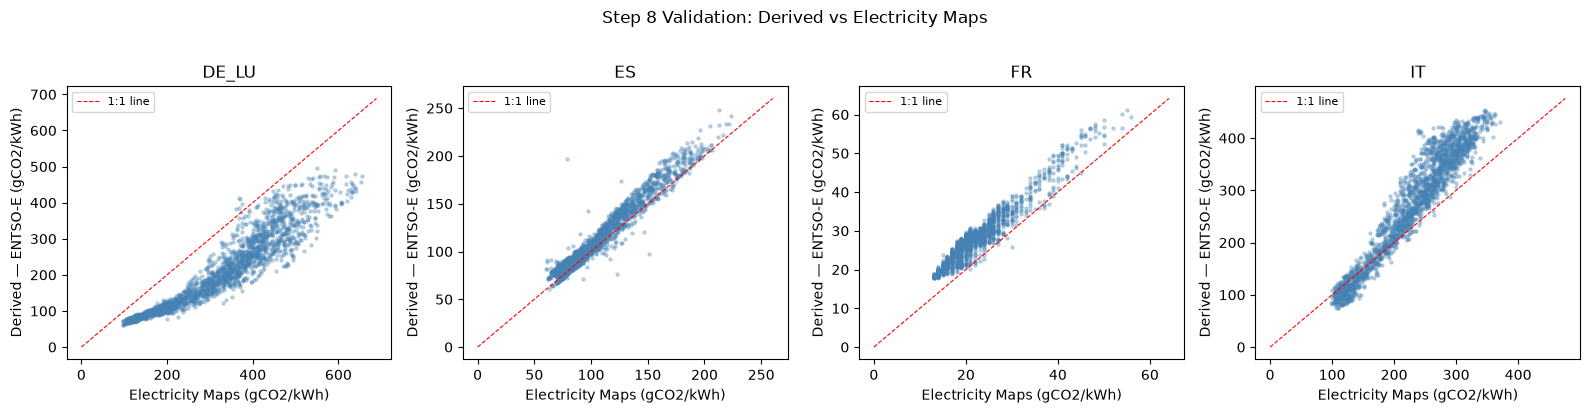

In [18]:
import matplotlib.pyplot as plt

scatter_data = query("""
    SELECT
        d.country,
        d.gco2_per_kwh  AS derived,
        e.gco2_per_kwh  AS electricitymaps
    FROM carbon_intensity d
    JOIN carbon_intensity e
        ON  e.country       = d.country
        AND e.timestamp_utc = d.timestamp_utc
        AND e.method        = 'electricitymaps'
    WHERE d.method  = 'derived'
      AND d.country != 'GB'
""")

if len(scatter_data) == 0:
    print("No overlap data available for scatter plot.")
else:
    countries = scatter_data['country'].unique()
    n = len(countries)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, country in zip(axes, sorted(countries)):
        subset = scatter_data[scatter_data['country'] == country]
        ax.scatter(subset['electricitymaps'], subset['derived'],
                   alpha=0.3, s=5, color='steelblue')

        # Diagonal reference line (perfect agreement)
        lim_max = max(subset['electricitymaps'].max(), subset['derived'].max()) * 1.05
        ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=0.8, label='1:1 line')

        ax.set_xlabel("Electricity Maps (gCO2/kWh)")
        ax.set_ylabel("Derived — ENTSO-E (gCO2/kWh)")
        ax.set_title(country)
        ax.legend(fontsize=8)

    plt.suptitle("Step 8 Validation: Derived vs Electricity Maps", y=1.02)
    plt.tight_layout()
    plt.show()

### D5. Investigate high-MAE hours (if any country failed)
If a country's MAE exceeds the threshold, this query surfaces the worst-offending hours
to help diagnose the root cause — typically a source-type mapping issue.

In [20]:
# Set this to the country you want to investigate — e.g. 'DE_LU', 'ES', 'IT'
INVESTIGATE_COUNTRY = 'IT'

worst_hours = query("""
    SELECT
        d.country,
        d.timestamp_utc,
        d.gco2_per_kwh                               AS derived,
        e.gco2_per_kwh                               AS electricitymaps,
        ABS(d.gco2_per_kwh - e.gco2_per_kwh)        AS abs_error
    FROM carbon_intensity d
    JOIN carbon_intensity e
        ON  e.country       = d.country
        AND e.timestamp_utc = d.timestamp_utc
        AND e.method        = 'electricitymaps'
    WHERE d.method  = 'derived'
      AND d.country = %(country)s
    ORDER BY abs_error DESC
    LIMIT 20
""", params={'country': INVESTIGATE_COUNTRY})

if len(worst_hours) == 0:
    print(f"No overlap data for {INVESTIGATE_COUNTRY}.")
else:
    print(f"Top 20 worst-error hours for {INVESTIGATE_COUNTRY}:")
    print(worst_hours.to_string(index=False))

Top 20 worst-error hours for IT:
country             timestamp_utc  derived  electricitymaps  abs_error
     IT 2026-04-28 02:00:00+00:00   414.55            239.0     175.55
     IT 2026-04-28 01:00:00+00:00   413.02            239.0     174.02
     IT 2026-04-28 03:00:00+00:00   414.35            242.0     172.35
     IT 2026-04-27 23:00:00+00:00   409.88            238.0     171.88
     IT 2026-04-28 00:00:00+00:00   410.12            241.0     169.12
     IT 2026-04-27 22:00:00+00:00   410.72            243.0     167.72
     IT 2026-04-27 21:00:00+00:00   420.15            262.0     158.15
     IT 2026-04-28 04:00:00+00:00   403.69            247.0     156.69
     IT 2026-04-27 20:00:00+00:00   422.14            270.0     152.14
     IT 2026-04-27 19:00:00+00:00   421.03            276.0     145.03
     IT 2026-06-06 00:00:00+00:00   396.64            254.0     142.64
     IT 2026-04-27 18:00:00+00:00   419.46            279.0     140.46
     IT 2026-06-06 01:00:00+00:00   396.26  

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2458919853.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section E — Findings Summary

### E1. Combined summary table — derived statistics + validation results

In [22]:
summary = query("""
    SELECT
        ci.country,
        COUNT(*)                                                        AS derived_hours,
        ROUND(MIN(ci.gco2_per_kwh), 1)                                 AS min_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY ci.gco2_per_kwh)
        AS numeric), 1)                                                 AS median_gco2,
        ROUND(MAX(ci.gco2_per_kwh), 1)                                 AS max_gco2
    FROM carbon_intensity ci
    WHERE ci.method = 'derived'
    GROUP BY ci.country
    ORDER BY ci.country
""")

print("=" * 60)
print("STEP 7 & 8 — FINDINGS SUMMARY")
print("=" * 60)
print()
print("Derived carbon intensity (gCO2/kWh):")
print(summary.to_string(index=False))
print()

if len(validation) > 0:
    print("Step 8 validation — MAE vs Electricity Maps:")
    print(validation[['country', 'matched_hours', 'mae', 'correlation_r', 'mean_bias']].to_string(index=False))
    print()
    print("Methodological notes:")
    print()
    print("  FR, ES — PASS (MAE ≤ 20)")
    print("    Low fossil fuel share means emission factor differences have minimal impact.")
    print("    Cross-border import volumes are modest relative to domestic generation.")
    print()
    print("  IT — MAE 48.49 (FAIL threshold, but methodological — not a data error)")
    print("    Derived (production-based) systematically HIGHER than Electricity Maps.")
    print("    Italy is a net importer of low-carbon electricity from FR, CH, AT.")
    print("    EM's consumption-based flow-tracing attributes imported low-carbon power")
    print("    to Italian consumers, lowering EM's intensity. Our production-based method")
    print("    sees only Italy's domestic gas-heavy generation mix, so derived > EM.")
    print("    Worst hours: late April and early June nights — peak spring hydro import season.")
    print()
    print("  DE_LU — MAE 109.64 (FAIL threshold, methodological divergence — two causes)")
    print("    Derived (production-based) systematically LOWER than Electricity Maps.")
    print("    Cause 1 — Grid-specific emission factors:")
    print("      EM uses EU-ETS reported emissions divided by ENTSO-E generation (actual")
    print("      plant-level data), updated annually. Germany has high lignite (brown coal)")
    print("      share; actual lignite emission intensity (~900–1200 gCO2/kWh) exceeds")
    print("      the IPCC AR5 generic coal median (820) used in our derived calculation.")
    print("      This causes EM to be structurally higher than our derived values.")
    print("    Cause 2 — Consumption-based vs production-based:")
    print("      EM applies flow-tracing to account for cross-border electricity trade.")
    print("      Germany is Europe's largest electricity trader; import/export volumes")
    print("      amplify the divergence between consumption-based and production-based")
    print("      intensity estimates.")
    print("    Note: ENTSO-E generation data for DE_LU confirmed intact for worst-error")
    print("    periods (coal and gas MW values normal) — data quality is not the issue.")
    print()
    print("  GB  — excluded from Step 8 validation and dispatch ranking.")
    print("    ENTSO-E coverage severely limited post-Brexit; derived values unreliable.")
    print()
    print("  MAE threshold: ≤ 20 gCO2/kWh (framework Step 8)")
    print("  IT and DE_LU failures reflect documented methodology differences,")
    print("  not errors in the ENTSO-E ingestion or carbon intensity calculation.")
else:
    print("Step 8 validation not available — run Electricity Maps ingestion first.")

STEP 7 & 8 — FINDINGS SUMMARY

Derived carbon intensity (gCO2/kWh):
country  derived_hours  min_gco2  median_gco2  max_gco2
  DE_LU          21403      58.1        339.2     556.7
     ES          21368      41.1        111.7     312.2
     FR          21373      17.8         29.6     103.0
     GB          20012      11.0         16.9     820.0
     IT          21403      73.9        360.9     481.0

Step 8 validation — MAE vs Electricity Maps:
country  matched_hours    mae  correlation_r  mean_bias
  DE_LU           2160 109.64         0.9424    -109.50
     ES           2160   8.56         0.9759       7.58
     FR           2160   5.70         0.9662       5.69
     IT           2160  48.49         0.9628      42.19

Methodological notes:

  FR, ES — PASS (MAE ≤ 20)
    Low fossil fuel share means emission factor differences have minimal impact.
    Cross-border import volumes are modest relative to domestic generation.

  IT — MAE 48.49 (FAIL threshold, but methodological — not a 

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_60676/2458919853.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### E2. Methodology note — key points for documentation

Points to include in the portfolio methodology note:

**Electricity Maps divergence**  
Electricity Maps computes carbon intensity using two methodological differences
from this analysis:

1. **Consumption-based vs production-based**: EM applies a flow-tracing algorithm
    that attributes imported electricity to the consuming country. This analysis uses
    production-based intensity (ENTSO-E domestic generation mix only). Net-importing
    countries (IT) show derived > EM because low-carbon imports (FR nuclear, CH hydro)
    are visible to EM but not to our calculation.

2. **Grid-specific vs IPCC generic emission factors**: In Europe, EM derives
    emission factors from EU-ETS reported plant-level emissions divided by ENTSO-E
    generation, updated annually. This captures country-specific fuel characteristics
    that IPCC AR5 generic medians do not — notably, Germany's high lignite share,
    where actual plant emissions (~900–1200 gCO2/kWh) exceed the IPCC coal median
    (820 gCO2/kWh) used here. This causes derived < EM for DE_LU.

These two effects act in opposite directions and vary in magnitude by country,
explaining why MAE is lowest for FR and ES (low fossil share, modest trade volumes)
and highest for DE_LU (high lignite share, large cross-border trade).

**Emission factor source**  
IPCC AR5 Annex III lifecycle median values. Gas = 490, Coal = 820, Nuclear = 12,
Wind onshore = 11, Solar PV = 45 gCO2/kWh. These are lifecycle factors (including
construction, operation, decommissioning), not combustion-only values. Renewable
sources therefore have a non-zero factor.

**Negative MW handling**  
Pumped storage and energy storage may report negative MW (charging mode).
These are clamped to zero in the calculation to avoid understating total generation
or introducing negative emission terms.

**NULL MW handling**  
NULL values in the generation table indicate ENTSO-E reporting gaps (documented
in `data_notes`). NULL sources contribute neither to the numerator nor denominator;
the derived value for that hour therefore reflects only the sources that did report.